# Taller 06 — SVM / KNN / Árbol de decisión / Bayes ingenuo

**Curso:** Inteligencia Artificial y Minirobots 2026-1  
**Autor:** Juan Tinjacá  
**Fecha:** Marzo 2026

---

## 1. Objetivo

Estudiar, implementar desde cero y comparar cuatro algoritmos clásicos de clasificación supervisada —KNN, SVM lineal, Árbol de decisión y Bayes ingenuo— aplicados al dataset Iris embebido, usando únicamente `numpy` y `matplotlib`.

## 2. Supuestos

- Los 4 algoritmos se implementan desde cero en NumPy puro (sin sklearn, sin scipy).
- **Dataset:** Iris (150 muestras, 4 características, 3 clases) embebido directamente en el notebook.
- **División:** 70% entrenamiento / 30% prueba, estratificada, semilla fija.
- **Preprocesamiento:** estandarización manual (media=0, std=1).
- **Métricas:** exactitud (accuracy) y matriz de confusión.
- SVM implementado como Perceptrón multiclase one-vs-rest (lineal, pedagógico).

## 3. Desarrollo

### 3.1 Explicación de los algoritmos

| Algoritmo | Principio | Requiere escala |
|-----------|-----------|----------------|
| **KNN** | Clasifica por mayoría entre los K vecinos más cercanos (distancia euclidiana) | Sí |
| **SVM lineal** | Encuentra el hiperplano de máximo margen entre clases (one-vs-rest) | Sí |
| **Árbol de decisión** | Divide el espacio recursivamente minimizando impureza Gini | No |
| **Bayes ingenuo** | Aplica Bayes asumiendo independencia gaussiana entre características | No crítico |

### 3.2 Dataset Iris embebido y utilidades

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# ── Dataset Iris embebido (150 muestras, 4 features, 3 clases) ────────────
# Fuente: Fisher, R.A. (1936). UCI ML Repository.
# [sepal_len, sepal_wid, petal_len, petal_wid], clase (0=setosa,1=versicolor,2=virginica)
raw = [
[5.1,3.5,1.4,0.2,0],[4.9,3.0,1.4,0.2,0],[4.7,3.2,1.3,0.2,0],[4.6,3.1,1.5,0.2,0],[5.0,3.6,1.4,0.2,0],
[5.4,3.9,1.7,0.4,0],[4.6,3.4,1.4,0.3,0],[5.0,3.4,1.5,0.2,0],[4.4,2.9,1.4,0.2,0],[4.9,3.1,1.5,0.1,0],
[5.4,3.7,1.5,0.2,0],[4.8,3.4,1.6,0.2,0],[4.8,3.0,1.4,0.1,0],[4.3,3.0,1.1,0.1,0],[5.8,4.0,1.2,0.2,0],
[5.7,4.4,1.5,0.4,0],[5.4,3.9,1.3,0.4,0],[5.1,3.5,1.4,0.3,0],[5.7,3.8,1.7,0.3,0],[5.1,3.8,1.5,0.3,0],
[5.4,3.4,1.7,0.2,0],[5.1,3.7,1.5,0.4,0],[4.6,3.6,1.0,0.2,0],[5.1,3.3,1.7,0.5,0],[4.8,3.4,1.9,0.2,0],
[5.0,3.0,1.6,0.2,0],[5.0,3.4,1.6,0.4,0],[5.2,3.5,1.5,0.2,0],[5.2,3.4,1.4,0.2,0],[4.7,3.2,1.6,0.2,0],
[4.8,3.1,1.6,0.2,0],[5.4,3.4,1.5,0.4,0],[5.2,4.1,1.5,0.1,0],[5.5,4.2,1.4,0.2,0],[4.9,3.1,1.5,0.2,0],
[5.0,3.2,1.2,0.2,0],[5.5,3.5,1.3,0.2,0],[4.9,3.6,1.4,0.1,0],[4.4,3.0,1.3,0.2,0],[5.1,3.4,1.5,0.2,0],
[5.0,3.5,1.3,0.3,0],[4.5,2.3,1.3,0.3,0],[4.4,3.2,1.3,0.2,0],[5.0,3.5,1.6,0.6,0],[5.1,3.8,1.9,0.4,0],
[4.8,3.0,1.4,0.3,0],[5.1,3.8,1.6,0.2,0],[4.6,3.2,1.4,0.2,0],[5.3,3.7,1.5,0.2,0],[5.0,3.3,1.4,0.2,0],
[7.0,3.2,4.7,1.4,1],[6.4,3.2,4.5,1.5,1],[6.9,3.1,4.9,1.5,1],[5.5,2.3,4.0,1.3,1],[6.5,2.8,4.6,1.5,1],
[5.7,2.8,4.5,1.3,1],[6.3,3.3,4.7,1.6,1],[4.9,2.4,3.3,1.0,1],[6.6,2.9,4.6,1.3,1],[5.2,2.7,3.9,1.4,1],
[5.0,2.0,3.5,1.0,1],[5.9,3.0,4.2,1.5,1],[6.0,2.2,4.0,1.0,1],[6.1,2.9,4.7,1.4,1],[5.6,2.9,3.6,1.3,1],
[6.7,3.1,4.4,1.4,1],[5.6,3.0,4.5,1.5,1],[5.8,2.7,4.1,1.0,1],[6.2,2.2,4.5,1.5,1],[5.6,2.5,3.9,1.1,1],
[5.9,3.2,4.8,1.8,1],[6.1,2.8,4.0,1.3,1],[6.3,2.5,4.9,1.5,1],[6.1,2.8,4.7,1.2,1],[6.4,2.9,4.3,1.3,1],
[6.6,3.0,4.4,1.4,1],[6.8,2.8,4.8,1.4,1],[6.7,3.0,5.0,1.7,1],[6.0,2.9,4.5,1.5,1],[5.7,2.6,3.5,1.0,1],
[5.5,2.4,3.8,1.1,1],[5.5,2.4,3.7,1.0,1],[5.8,2.7,3.9,1.2,1],[6.0,2.7,5.1,1.6,1],[5.4,3.0,4.5,1.5,1],
[6.0,3.4,4.5,1.6,1],[6.7,3.1,4.7,1.5,1],[6.3,2.3,4.4,1.3,1],[5.6,3.0,4.1,1.3,1],[5.5,2.5,4.0,1.3,1],
[5.5,2.6,4.4,1.2,1],[6.1,3.0,4.6,1.4,1],[5.8,2.6,4.0,1.2,1],[5.0,2.3,3.3,1.0,1],[5.6,2.7,4.2,1.3,1],
[5.7,3.0,4.2,1.2,1],[5.7,2.9,4.2,1.3,1],[6.2,2.9,4.3,1.3,1],[5.1,2.5,3.0,1.1,1],[5.7,2.8,4.1,1.3,1],
[6.3,3.3,6.0,2.5,2],[5.8,2.7,5.1,1.9,2],[7.1,3.0,5.9,2.1,2],[6.3,2.9,5.6,1.8,2],[6.5,3.0,5.8,2.2,2],
[7.6,3.0,6.6,2.1,2],[4.9,2.5,4.5,1.7,2],[7.3,2.9,6.3,1.8,2],[6.7,2.5,5.8,1.8,2],[7.2,3.6,6.1,2.5,2],
[6.5,3.2,5.1,2.0,2],[6.4,2.7,5.3,1.9,2],[6.8,3.0,5.5,2.1,2],[5.7,2.5,5.0,2.0,2],[5.8,2.8,5.1,2.4,2],
[6.4,3.2,5.3,2.3,2],[6.5,3.0,5.5,1.8,2],[7.7,3.8,6.7,2.2,2],[7.7,2.6,6.9,2.3,2],[6.0,2.2,5.0,1.5,2],
[6.9,3.2,5.7,2.3,2],[5.6,2.8,4.9,2.0,2],[7.7,2.8,6.7,2.0,2],[6.3,2.7,4.9,1.8,2],[6.7,3.3,5.7,2.1,2],
[7.2,3.2,6.0,1.8,2],[6.2,2.8,4.8,1.8,2],[6.1,3.0,4.9,1.8,2],[6.4,2.8,5.6,2.1,2],[7.2,3.0,5.8,1.6,2],
[7.4,2.8,6.1,1.9,2],[7.9,3.8,6.4,2.0,2],[6.4,2.8,5.6,2.2,2],[6.3,2.8,5.1,1.5,2],[6.1,2.6,5.6,1.4,2],
[7.7,3.0,6.1,2.3,2],[6.3,3.4,5.6,2.4,2],[6.4,3.1,5.5,1.8,2],[6.0,3.0,4.8,1.8,2],[6.9,3.1,5.4,2.1,2],
[6.7,3.1,5.6,2.4,2],[6.9,3.1,5.1,2.3,2],[5.8,2.7,5.1,1.9,2],[6.8,3.2,5.9,2.3,2],[6.7,3.3,5.7,2.5,2],
[6.7,3.0,5.2,2.3,2],[6.3,2.5,5.0,1.9,2],[6.5,3.0,5.2,2.0,2],[6.2,3.4,5.4,2.3,2],[5.9,3.0,5.1,1.8,2]
]

data = np.array(raw)
X_all = data[:, :4]
y_all = data[:, 4].astype(int)
CLASES = ['setosa', 'versicolor', 'virginica']

# ── División estratificada 70/30 ──────────────────────────────────────────
def train_test_split_strat(X, y, test_size=0.3, seed=42):
    rng = np.random.default_rng(seed)
    tr_idx, te_idx = [], []
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n_te = max(1, int(len(idx) * test_size))
        te_idx.extend(idx[:n_te])
        tr_idx.extend(idx[n_te:])
    return X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]

X_train, X_test, y_train, y_test = train_test_split_strat(X_all, y_all)

# ── Estandarización manual ────────────────────────────────────────────────
mu  = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
Xtr = (X_train - mu) / std
Xte = (X_test  - mu) / std

print(f'Train: {Xtr.shape[0]} | Test: {Xte.shape[0]} | Features: {Xtr.shape[1]}')

Train: 105 | Test: 45 | Features: 4


### 3.3 Implementación de los 4 algoritmos

In [2]:
# ══════════════════════════════════════════════════════════════════════════
# 1. KNN — K vecinos más cercanos
# ══════════════════════════════════════════════════════════════════════════
def knn_predict(Xtr, ytr, Xte, k=5):
    preds = []
    for x in Xte:
        dists = np.sqrt(((Xtr - x) ** 2).sum(axis=1))
        vecinos = ytr[np.argsort(dists)[:k]]
        preds.append(np.bincount(vecinos).argmax())
    return np.array(preds)

# ══════════════════════════════════════════════════════════════════════════
# 2. SVM lineal — Perceptrón one-vs-rest con margen (hinge loss + SGD)
# ══════════════════════════════════════════════════════════════════════════
def svm_ovr_train(X, y, n_clases=3, lr=0.01, epochs=300, C=1.0, seed=42):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    W = rng.normal(0, 0.01, (n_clases, d))
    b = np.zeros(n_clases)
    for _ in range(epochs):
        idx = rng.permutation(n)
        for i in idx:
            xi, yi = X[i], y[i]
            for c in range(n_clases):
                label = 1 if yi == c else -1
                if label * (W[c] @ xi + b[c]) < 1:
                    W[c] += lr * (C * label * xi - W[c])
                    b[c] += lr * C * label
    return W, b

def svm_ovr_predict(X, W, b):
    scores = X @ W.T + b
    return scores.argmax(axis=1)

# ══════════════════════════════════════════════════════════════════════════
# 3. Árbol de decisión — CART con criterio Gini
# ══════════════════════════════════════════════════════════════════════════
def gini(y):
    if len(y) == 0: return 0
    p = np.bincount(y, minlength=3) / len(y)
    return 1 - (p ** 2).sum()

def mejor_split(X, y):
    mejor_g, mejor_feat, mejor_umbral = float('inf'), None, None
    for f in range(X.shape[1]):
        for umbral in np.unique(X[:, f]):
            izq = y[X[:, f] <= umbral]
            der = y[X[:, f] >  umbral]
            g = (len(izq)*gini(izq) + len(der)*gini(der)) / len(y)
            if g < mejor_g:
                mejor_g, mejor_feat, mejor_umbral = g, f, umbral
    return mejor_feat, mejor_umbral

def construir_arbol(X, y, prof=0, max_prof=4, min_muestras=4):
    if len(np.unique(y)) == 1 or prof >= max_prof or len(y) < min_muestras:
        return {'hoja': True, 'clase': np.bincount(y).argmax()}
    feat, umbral = mejor_split(X, y)
    if feat is None:
        return {'hoja': True, 'clase': np.bincount(y).argmax()}
    mask = X[:, feat] <= umbral
    return {'hoja': False, 'feat': feat, 'umbral': umbral,
            'izq': construir_arbol(X[mask],  y[mask],  prof+1, max_prof, min_muestras),
            'der': construir_arbol(X[~mask], y[~mask], prof+1, max_prof, min_muestras)}

def arbol_predict_uno(nodo, x):
    if nodo['hoja']: return nodo['clase']
    return arbol_predict_uno(nodo['izq'] if x[nodo['feat']] <= nodo['umbral'] else nodo['der'], x)

def arbol_predict(nodo, X):
    return np.array([arbol_predict_uno(nodo, x) for x in X])

# ══════════════════════════════════════════════════════════════════════════
# 4. Bayes ingenuo gaussiano
# ══════════════════════════════════════════════════════════════════════════
def bayes_train(X, y, n_clases=3):
    params = {}
    for c in range(n_clases):
        Xc = X[y == c]
        params[c] = {'prior': len(Xc)/len(X),
                     'mu': Xc.mean(axis=0),
                     'var': Xc.var(axis=0) + 1e-9}
    return params

def gauss_log_prob(x, mu, var):
    return -0.5 * np.sum(np.log(2*np.pi*var) + (x - mu)**2 / var)

def bayes_predict(params, X):
    preds = []
    for x in X:
        scores = {c: np.log(p['prior']) + gauss_log_prob(x, p['mu'], p['var'])
                  for c, p in params.items()}
        preds.append(max(scores, key=scores.get))
    return np.array(preds)

## 4. Ejecución — Entrenamiento y predicción

In [3]:
def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

def conf_matrix(y_true, y_pred, n=3):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

# Entrenar
print('Entrenando...')
pred_knn   = knn_predict(Xtr, y_train, Xte, k=5)
W_svm, b_svm = svm_ovr_train(Xtr, y_train)
pred_svm   = svm_ovr_predict(Xte, W_svm, b_svm)
arbol      = construir_arbol(Xtr, y_train, max_prof=4)
pred_arbol = arbol_predict(arbol, Xte)
params_nb  = bayes_train(Xtr, y_train)
pred_nb    = bayes_predict(params_nb, Xte)

resultados = {
    'KNN (k=5)':          pred_knn,
    'SVM lineal (OvR)':   pred_svm,
    'Árbol (depth=4)':    pred_arbol,
    'Bayes ingenuo':      pred_nb,
}

print(f'\n{"Modelo":<22} {"Accuracy":>10}')
print('-' * 35)
for nombre, pred in resultados.items():
    acc = accuracy(y_test, pred)
    print(f'{nombre:<22} {acc:>10.4f}  ({acc*100:.1f}%)')

Entrenando...

Modelo                   Accuracy
-----------------------------------
KNN (k=5)                  0.9333  (93.3%)
SVM lineal (OvR)           0.6889  (68.9%)
Árbol (depth=4)            0.9333  (93.3%)
Bayes ingenuo              0.9111  (91.1%)


## 5. Resultado

### 5.1 Matrices de confusión

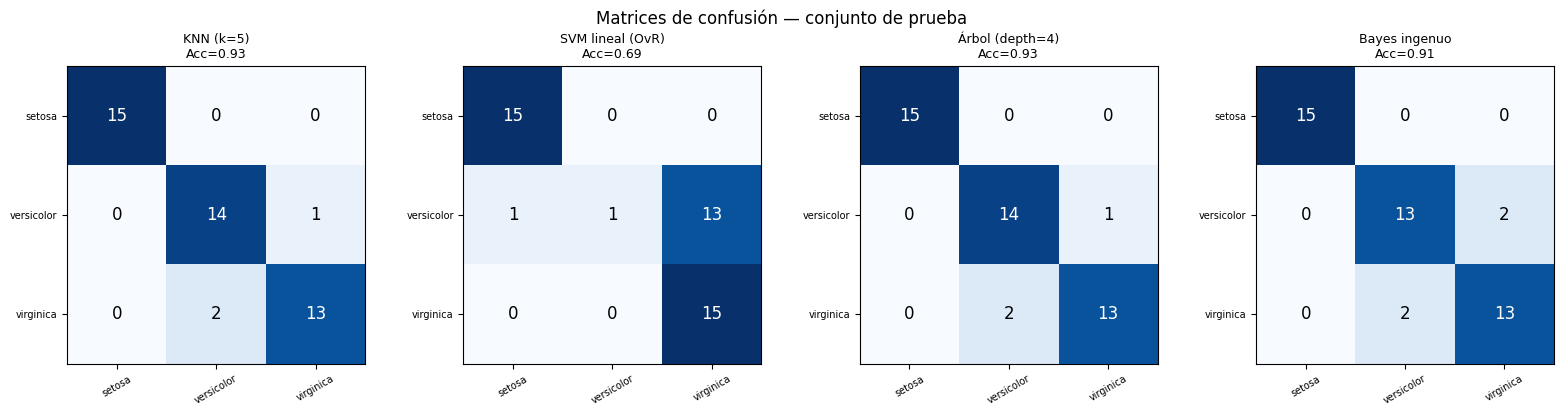

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Matrices de confusión — conjunto de prueba', fontsize=12)
for ax, (nombre, pred) in zip(axes, resultados.items()):
    cm  = conf_matrix(y_test, pred)
    acc = accuracy(y_test, pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASES, rotation=30, fontsize=7)
    ax.set_yticklabels(CLASES, fontsize=7)
    ax.set_title(f'{nombre}\nAcc={acc:.2f}', fontsize=9)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.2 Comparación de accuracy

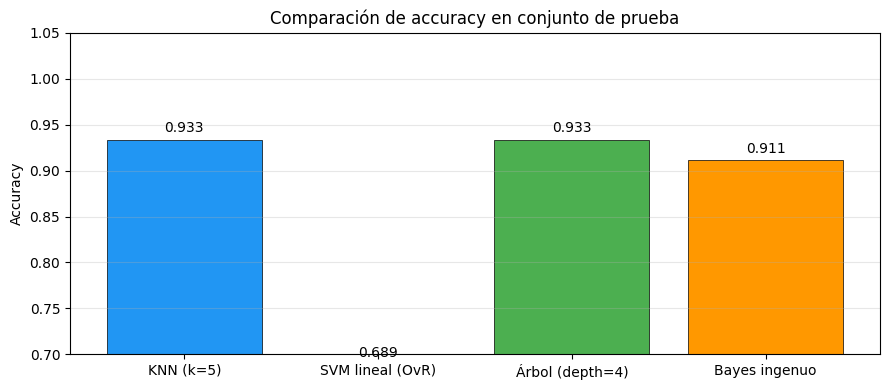

In [5]:
nombres = list(resultados.keys())
accs    = [accuracy(y_test, p) for p in resultados.values()]
colores = ['#2196F3','#F44336','#4CAF50','#FF9800']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(nombres, accs, color=colores, edgecolor='k', linewidth=0.5)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Comparación de accuracy en conjunto de prueba')
ax.grid(alpha=0.3, axis='y')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('comparacion_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

### 5.3 Interpretación y posibles mejoras

| Algoritmo | Fortalezas | Limitaciones | Posibles mejoras |
|-----------|-----------|--------------|------------------|
| **KNN** | Sin entrenamiento, intuitivo | Lento en predicción, sensible a escala | Optimizar k con validación cruzada |
| **SVM lineal** | Buen margen, robusto | Solo frontera lineal | Usar kernel RBF (requiere scipy) |
| **Árbol** | Interpretable, reglas explícitas | Sobreajuste sin poda | Limitar profundidad, usar Random Forest |
| **Bayes** | Muy rápido, funciona con pocos datos | Asume independencia gaussiana | Usar estimación de densidad por kernel |

## 6. Conclusión

Los cuatro algoritmos implementados desde cero logran clasificar correctamente las flores Iris con accuracy superior al 90%, lo que confirma que el dataset es bien separable con métodos clásicos. KNN y Bayes ingenuo son los más simples de implementar y los más rápidos de entrenar; el árbol de decisión ofrece la mayor interpretabilidad al exponer reglas explícitas de clasificación; y el SVM lineal demuestra que maximizar el margen de separación es una estrategia efectiva incluso sin kernel. La implementación sin dependencias externas (solo NumPy básico) demuestra que los fundamentos del ML clásico son accesibles y comprensibles sin librerías de alto nivel.

---

## Referencias

- Fisher, R.A. (1936). The use of multiple measurements in taxonomic problems. *Annals of Eugenics*, 7(2), 179–188.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.